# Metrics Evaluation Notebook

Evaluates **Random**, **PPO**, and **Genetic Algorithm** agents across all coverage metrics.
Random and PPO results are loaded from saved JSON if available (no re-run needed).
The GA model is loaded from a `.pth` file.


## Setup

In [ ]:
from google.colab import drive, userdata
drive.mount('/content/drive')

FOLDER_PATH     = userdata.get('reinforcementLearningFolderPath')
CHECKPOINT_DIR  = '/content/drive/MyDrive/smw-checkpoints-ppo-v2/'
PPO_MODEL_NAME  = 'ppo_trythings_v1_final'   #

#
GA_MODEL_PATH   = '/content/drive/MyDrive/trained_smarter_genetic_algorithm_full_fps.pth'

ROMS_PATH       = f"{FOLDER_PATH}/Project/roms"

import os, glob
os.makedirs('./figures', exist_ok=True)


Mounted at /content/drive


In [ ]:
!mkdir -p roms
!cp -r "$ROMS_PATH" ./
!git clone https://github.com/HenriqueSchmitz/mario-the-explorer
!sh ./mario-the-explorer/setup.sh
!pip install -q stable-baselines3 matplotlib

Cloning into 'mario-the-explorer'...
remote: Enumerating objects: 375, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 375 (delta 15), reused 30 (delta 12), pack-reused 335 (from 1)
Receiving objects: 100% (375/375), 24.34 MiB | 19.30 MiB/s, done.
Resolving deltas: 100% (190/190), done.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 230.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 195.6 MB/s eta 0:00:00
Importing SuperMarioWorld-Snes-v0
Imported 1 games
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 33.

In [ ]:
from typing import Optional
from enum import Enum
from collections import Counter
import math

import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from stable_baselines3 import PPO

from mario_the_explorer import (
    SuperMarioWorldLayeredEmulator, RewardModel, ScreenOverlay, Tile,
    get_file_logger, tile_absolute_id, TileEncoder, SuperMarioAction,
    SuperMarioCombo, SuperMarioDiscretizer, TileType, ButtonStates,
    SCREEN_COLUMNS, SCREEN_ROWS, TILE_SIZE
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


Using device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Shared classes (copy from training notebook)

In [ ]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class Direction(Enum):
    LEFT  = 0
    RIGHT = 1
    UP    = 2
    DOWN  = 3


from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import torch
import torch.nn as nn

class CustomMarioCNN(BaseFeaturesExtractor):
    """
    Three convolutional layers followed by two fully-connected layers.
    Must match the training notebook exactly so saved checkpoints load cleanly.
    """
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512):
        super().__init__(observation_space, features_dim)
        nc = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(nc, 32,  kernel_size=3, stride=1), nn.ReLU(),
            nn.Conv2d(32, 64,  kernel_size=3, stride=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.cnn(
                torch.as_tensor(observation_space.sample()[None]).float()
            ).shape[1]
        self.linear = nn.Sequential(
            nn.Linear(n_flat,       features_dim), nn.ReLU(),
            nn.Linear(features_dim, features_dim), nn.ReLU(),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(obs))

# ── Shared reward model (identical to GA notebook) ────────────────────────────
class TryThingsRewardModel(RewardModel):
    def __init__(self, new_block_reward=10.0, action_reward=1.0, progression_reward=0.1):
        self._blocks_seen             = set()
        self._block_action_counts     = {}
        self._block_available_rewards = {}
        self._best_distance_reached   = 0
        self._new_block_reward        = new_block_reward
        self._action_reward           = action_reward
        self._progression_reward      = progression_reward
        self.MAX_BLOCK_REWARD         = self._get_total_reward_for_block()

    def reset(self):
        self._blocks_seen             = set()
        self._block_action_counts     = {}
        self._block_available_rewards = {}
        self._best_distance_reached   = 0

    def _get_total_reward_for_block(self, number_of_actions=10, number_of_directions=4):
        total = 0.0; prev = -1; n = 0
        while total != prev:
            prev = total; n += 1; total += self._reward_curve(n)
        return total * number_of_actions * number_of_directions

    def _reward_curve(self, action_count):
        r = self._action_reward / action_count
        return r if r >= 0.05 else 0.0

    def get_reward(self, action, observation, terminated, truncated, info):
        reward = 0.0
        for row in observation:
            for tile in row:
                tile_id = tile_absolute_id(tile)
                if tile['type'] in (TileType.EMPTY, TileType.MARIO):
                    self._block_available_rewards[tile_id] = 0; continue
                if tile_id not in self._blocks_seen:
                    self._blocks_seen.add(tile_id)
                    reward += 10.0
                    self._block_available_rewards[tile_id] = self.MAX_BLOCK_REWARD
        for tile_and_dir in self._get_tiles_around_mario(observation):
            combo_id = SuperMarioCombo.get_combo_id_from_action(action)
            if combo_id == SuperMarioCombo.DO_NOTHING: continue
            key = (combo_id, tile_and_dir[0], tile_and_dir[1])
            self._block_action_counts[key] = self._block_action_counts.get(key, 0) + 1
            ar = self._reward_curve(self._block_action_counts[key])
            self._block_available_rewards[tile_and_dir[1]] -= ar
            reward += ar
        if info['x'] > self._best_distance_reached:
            self._best_distance_reached = info['x']; reward += 0.1
        if terminated or truncated:
            vis = {tile_absolute_id(t) for row in observation for t in row}
            valid = max(len(vis) - 2, 1)
            avail = sum(self._block_available_rewards.values())
            reward -= (avail / (valid * self.MAX_BLOCK_REWARD)) * 20.0
        return reward

    def _get_tiles_around_mario(self, observation):
        result = set()
        for r, c in self._find_mario_coordinates(observation):
            for dr, dc, dname in [(-1,0,'UP'),(1,0,'DOWN'),(0,-1,'LEFT'),(0,1,'RIGHT')]:
                nr, nc = r+dr, c+dc
                if 0 <= nr < len(observation) and 0 <= nc < len(observation[0]):
                    t = observation[nr][nc]
                    if t['type'] not in (TileType.MARIO, TileType.EMPTY):
                        result.add((dname, tile_absolute_id(t)))
        return result

    def _find_mario_coordinates(self, observation):
        return [(r, c) for r, row in enumerate(observation)
                for c, t in enumerate(row) if t['type'] == TileType.MARIO]

    def get_potential_map(self, observation):
        h, w = len(observation), len(observation[0])
        pm = np.zeros((h, w), dtype=np.float32)
        for r in range(h):
            for c in range(w):
                tid = tile_absolute_id(observation[r][c])
                pm[r, c] = self._block_available_rewards.get(tid, 0.0) / self.MAX_BLOCK_REWARD
        return pm


class MarioReshapeWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        c, h, w = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(c+1, h, w), dtype=np.float32
        )
    def observation(self, obs):
        rm = self.env.unwrapped.reward_model
        hm = np.expand_dims(rm.get_potential_map(self.env.unwrapped.observation), 0)
        return np.concatenate([obs, hm], axis=0).astype(np.float32)


print('Classes defined.')


Classes defined.


## 3. Environment factory & metrics collector

In [ ]:
# ── Evaluation config ─────────────────────────────────────────────────────────
LEVEL        = 'DonutPlains1'
MAX_STEPS    = 10000
N_EPISODES   = 20
ACTION_NAMES = [
    'NOOP', 'LEFT', 'RIGHT', 'RIGHT+RUN',
    'RIGHT+JMP', 'RIGHT+RUN+JMP', 'JUMP', 'DOWN',
    'LEFT+RUN', 'LEFT+JMP', 'LEFT+RUN+JMP'
]
N_ACTIONS = len(ACTION_NAMES)


_reward_model = TryThingsRewardModel()
_base_env = SuperMarioWorldLayeredEmulator(
    level=LEVEL, render_mode='rgb_array',
    reward_model=_reward_model,
    render_debug=False, render_grid=False,
    max_episode_length=MAX_STEPS,
    limit_fps_to=None,
)
_disc_env  = SuperMarioDiscretizer(_base_env)
ENV        = MarioReshapeWrapper(_disc_env)


def collect_episode_metrics(info_final, actions_taken, ep_reward, max_x):
    blocks_seen = _reward_model._blocks_seen
    terrain_ids = {tid for tid in blocks_seen if 256*3 <= tid < 256*5}
    sprite_ids  = {tid for tid in blocks_seen if 256*1 <= tid < 256*2}
    ext_ids     = {tid for tid in blocks_seen if 256*2 <= tid < 256*3}

    counts = np.array([actions_taken.count(a) for a in range(N_ACTIONS)], dtype=float)
    probs  = counts / counts.sum() if counts.sum() > 0 else np.ones(N_ACTIONS) / N_ACTIONS
    entropy = -np.sum(probs[probs > 0] * np.log(probs[probs > 0]))

    return {
        'episode_reward':          ep_reward,
        'unique_terrain_tiles':    len(terrain_ids),
        'unique_sprite_types':     len(sprite_ids),
        'unique_ext_sprite_types': len(ext_ids),
        'max_x':                   max_x,           # tracked step-by-step, not from final info
        'tile_interactions':       info_final.get('episode_interactions', 0),
        'deaths':                  info_final.get('episode_deaths', 0),
        'action_entropy':          entropy,
        'goal_reached':            bool(info_final.get('goal_reached', False)),
        'action_counts':           counts.tolist(),
        'unique_tiles_over_time':  None,
    }


def run_episode(policy_fn):
    obs, info = ENV.reset()
    done = False
    ep_reward = 0.0
    actions_taken = []
    unique_tile_curve = []
    seen_terrain = set()
    max_x = 0   # tracked every step — not read from final info

    while not done:
        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = ENV.step(action)
        ep_reward += reward
        actions_taken.append(int(action))
        done = terminated or truncated

        # Track max x every step
        max_x = max(max_x, int(info.get('mario_x', 0)))

        terrain_now = {tid for tid in _reward_model._blocks_seen if 256*3 <= tid < 256*5}
        seen_terrain |= terrain_now
        unique_tile_curve.append(len(seen_terrain))

    metrics = collect_episode_metrics(info, actions_taken, ep_reward, max_x)
    metrics['unique_tiles_over_time'] = unique_tile_curve
    return metrics


def evaluate_agent(label, policy_fn, n_episodes=N_EPISODES):
    results = []
    for ep in range(n_episodes):
        m = run_episode(policy_fn)
        results.append(m)
        print(
            f'[{label}] ep {ep+1:2d}/{n_episodes}  '
            f'reward={m["episode_reward"]:7.1f}  '
            f'terrain={m["unique_terrain_tiles"]:3d}  '
            f'sprites={m["unique_sprite_types"]:2d}  '
            f'ext={m["unique_ext_sprite_types"]:2d}  '
            f'max_x={m["max_x"]:5d}  '
            f'goal={m["goal_reached"]}'
        )
    return results


## 4. Random policy baseline

In [24]:
random_policy = lambda obs: np.random.randint(N_ACTIONS)
random_results = evaluate_agent('Random', random_policy, n_episodes=N_EPISODES)

[Random] ep  1/20  reward=   91.5  terrain=  5  sprites= 0  ext= 0  max_x=   59  goal=False
[Random] ep  2/20  reward=  301.6  terrain=  5  sprites= 0  ext= 0  max_x=  117  goal=False
[Random] ep  3/20  reward=  346.7  terrain=  5  sprites= 0  ext= 0  max_x=  205  goal=False
[Random] ep  4/20  reward=  260.3  terrain=  5  sprites= 0  ext= 0  max_x=  148  goal=False
[Random] ep  5/20  reward=  371.0  terrain=  5  sprites= 0  ext= 0  max_x=  154  goal=False
[Random] ep  6/20  reward=  274.2  terrain=  5  sprites= 0  ext= 0  max_x=   94  goal=False
[Random] ep  7/20  reward=  346.3  terrain=  5  sprites= 0  ext= 0  max_x=  114  goal=False
[Random] ep  8/20  reward=  322.5  terrain=  5  sprites= 0  ext= 0  max_x=  173  goal=False
[Random] ep  9/20  reward=  340.8  terrain=  5  sprites= 0  ext= 0  max_x=  102  goal=False
[Random] ep 10/20  reward=  405.7  terrain=  5  sprites= 0  ext= 0  max_x=  190  goal=False
[Random] ep 11/20  reward=   94.8  terrain=  5  sprites= 0  ext= 0  max_x=   64 

## 5. PPO policy

In [ ]:
# ── Load the latest PPO checkpoint ───────────────────────────────────────────
checkpoints = sorted([
    f for f in glob.glob(CHECKPOINT_DIR + f'{PPO_MODEL_NAME}_*.zip')
    if 'final' not in f
])
if checkpoints:
    ppo_path = checkpoints[-1]
else:
    ppo_path = CHECKPOINT_DIR + f'{PPO_MODEL_NAME}.zip'

print(f'Loading PPO model from: {ppo_path}')

# Pass the already-open ENV for the obs/act space — no extra emulator created
ppo_model = PPO.load(
    ppo_path,
    env=ENV,
    device=device,
    custom_objects={
        'policy_kwargs': dict(
            features_extractor_class=CustomMarioCNN,
            features_extractor_kwargs=dict(features_dim=512)
        )
    }
)
print(f'PPO model loaded — timesteps trained: {ppo_model.num_timesteps:,}')


Loading PPO model from: /content/drive/MyDrive/smw-checkpoints-ppo-v2/ppo_trythings_v1_final.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO model loaded — timesteps trained: 1,001,472


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Stochastic PPO policy
ppo_policy = lambda obs: int(ppo_model.predict(obs, deterministic=False)[0])
ppo_results = evaluate_agent('PPO', ppo_policy, n_episodes=N_EPISODES)

[PPO] ep  1/20  reward=  409.6  terrain= 12  sprites= 3  ext= 0  max_x=  493  goal=False
[PPO] ep  2/20  reward=  202.7  terrain=  7  sprites= 1  ext= 0  max_x=  310  goal=False
[PPO] ep  3/20  reward=  313.2  terrain= 12  sprites= 1  ext= 0  max_x=  462  goal=False
[PPO] ep  4/20  reward=  463.0  terrain= 13  sprites= 5  ext= 1  max_x=  811  goal=False
[PPO] ep  5/20  reward=  512.5  terrain= 13  sprites= 6  ext= 1  max_x=  903  goal=False
[PPO] ep  6/20  reward=  524.1  terrain= 13  sprites= 6  ext= 1  max_x=  924  goal=False
[PPO] ep  7/20  reward=  334.7  terrain= 12  sprites= 1  ext= 0  max_x=  495  goal=False
[PPO] ep  8/20  reward=  199.5  terrain=  7  sprites= 1  ext= 0  max_x=  318  goal=False
[PPO] ep  9/20  reward=  333.4  terrain= 12  sprites= 1  ext= 0  max_x=  478  goal=False
[PPO] ep 10/20  reward=  340.4  terrain= 12  sprites= 3  ext= 0  max_x=  450  goal=False
[PPO] ep 11/20  reward=  228.6  terrain=  7  sprites= 1  ext= 0  max_x=  348  goal=False
[PPO] ep 12/20  rewar

## Genetic Algorithm policy

In [ ]:
class GACustomMarioCNN(nn.Module):
    def __init__(self, observation_space, features_dim=512, action_space=11):
        super().__init__()
        nc = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(nc, 32, kernel_size=3, stride=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            sample = torch.as_tensor(observation_space.sample()[None]).float()
            n_flat = self.cnn(sample).shape[1]
        self.linear = nn.Sequential(
            nn.Linear(n_flat, features_dim), nn.ReLU(),
            nn.Linear(features_dim, features_dim), nn.ReLU(),
        )
        self.output = nn.Sequential(
            nn.Linear(features_dim, action_space),
            nn.Softmax(dim=-1),
        )

    def forward(self, observations, deterministic=False):
        feats = self.linear(self.cnn(observations))
        probs = self.output(feats)
        if deterministic:
            return probs.argmax(dim=-1)
        return torch.multinomial(probs, num_samples=1, replacement=True).squeeze(-1)

In [ ]:
import torch

print(f'Loading GA model from: {GA_MODEL_PATH}')

loaded = torch.load(GA_MODEL_PATH, map_location='cpu', weights_only=False)
state_dict = loaded['state_dict']
params     = loaded['params']

# Instantiate using the EXACT same observation_space the GA was trained with
ga_net = GACustomMarioCNN(
    observation_space = params['observation_space'],
    features_dim      = params['features_dim'],
    action_space      = params['action_space'],
)
ga_net.load_state_dict(state_dict)
ga_net.eval()
print('GA model loaded.')

Loading GA model from: /content/drive/MyDrive/trained_smarter_genetic_algorithm_full_fps.pth
GA model loaded.


In [ ]:
def ga_policy(obs):
    """
    Stochastic forward pass — samples from the softmax distribution.
    deterministic=True always returns the same argmax from the same state,
    producing identical episodes. Stochastic sampling gives episode variance.
    """
    obs_tensor = torch.from_numpy(np.array(obs)).float().unsqueeze(0)
    with torch.no_grad():
        action = ga_net(obs_tensor, deterministic=False).item()
    return int(action)

ga_results = evaluate_agent('GA', ga_policy, n_episodes=N_EPISODES)

[GA] ep  1/20  reward=  486.1  terrain= 16  sprites= 5  ext= 2  max_x= 1347  goal=False
[GA] ep  2/20  reward=  250.1  terrain= 13  sprites= 1  ext= 0  max_x=  546  goal=False
[GA] ep  3/20  reward=  499.2  terrain= 16  sprites= 5  ext= 2  max_x= 1347  goal=False
[GA] ep  4/20  reward=  501.0  terrain= 16  sprites= 7  ext= 2  max_x= 1347  goal=False
[GA] ep  5/20  reward=  246.6  terrain= 13  sprites= 1  ext= 0  max_x=  545  goal=False
[GA] ep  6/20  reward=  447.0  terrain= 16  sprites= 5  ext= 2  max_x= 1346  goal=False
[GA] ep  7/20  reward=  247.2  terrain= 13  sprites= 1  ext= 0  max_x=  546  goal=False
[GA] ep  8/20  reward=  466.7  terrain= 16  sprites= 5  ext= 2  max_x= 1346  goal=False
[GA] ep  9/20  reward=  252.8  terrain= 13  sprites= 1  ext= 0  max_x=  542  goal=False
[GA] ep 10/20  reward=  248.5  terrain= 13  sprites= 1  ext= 0  max_x=  543  goal=False
[GA] ep 11/20  reward=  512.6  terrain= 16  sprites= 7  ext= 2  max_x= 1346  goal=False
[GA] ep 12/20  reward=  250.5  t

## Summary statistics

In [25]:
SCALAR_METRICS = [
    ('episode_reward',          'Episode reward'),
    ('unique_terrain_tiles',    'Unique terrain tiles'),
    ('unique_sprite_types',     'Unique sprite types'),
    ('unique_ext_sprite_types', 'Unique ext. sprite types'),
    ('max_x',                   'Max x-coord reached'),
    ('tile_interactions',       'Total tile interactions'),
    ('deaths',                  'Deaths per episode'),
    ('action_entropy',          'Action entropy H (nats)'),
]

def summarise(results, label):
    print(f'\n{"="*60}')
    print(f'  {label}  —  {len(results)} episodes')
    print(f'{"="*60}')
    for key, name in SCALAR_METRICS:
        v = [r[key] for r in results]
        print(f'  {name:<30s}  mean={np.mean(v):8.2f}  '
              f'std={np.std(v):6.2f}  '
              f'min={np.min(v):8.2f}  '
              f'max={np.max(v):8.2f}')
    goals = sum(r['goal_reached'] for r in results)
    print(f'  {"Secret exit found":<30s}  {goals}/{len(results)}')
    print()

summarise(random_results, 'RANDOM')
summarise(ppo_results,    'PPO')
summarise(ga_results,     'GA')



  RANDOM  —  20 episodes
  Episode reward                  mean=  279.44  std= 82.23  min=   91.47  max=  405.69
  Unique terrain tiles            mean=    5.00  std=  0.00  min=    5.00  max=    5.00
  Unique sprite types             mean=    0.00  std=  0.00  min=    0.00  max=    0.00
  Unique ext. sprite types        mean=    0.00  std=  0.00  min=    0.00  max=    0.00
  Max x-coord reached             mean=  133.65  std= 46.83  min=   59.00  max=  205.00
  Total tile interactions         mean=    0.00  std=  0.00  min=    0.00  max=    0.00
  Deaths per episode              mean=    0.00  std=  0.00  min=    0.00  max=    0.00
  Action entropy H (nats)         mean=    2.40  std=  0.00  min=    2.40  max=    2.40
  Secret exit found               0/20


  PPO  —  20 episodes
  Episode reward                  mean=  307.05  std=108.96  min=  175.06  max=  524.07
  Unique terrain tiles            mean=   10.00  std=  2.65  min=    7.00  max=   13.00
  Unique sprite types          

### Plots

In [ ]:
# ── Colour palette ───────────────────────────────────────────────────────────
COLORS = {
    'Random': '#8B949E',
    'PPO':    '#58A6FF',
    'GA':     '#F5A623',
}

agents = [
    ('Random', random_results),
    ('PPO',    ppo_results),
    ('GA',     ga_results),
]

def vals(results, key):
    return np.array([r[key] for r in results])


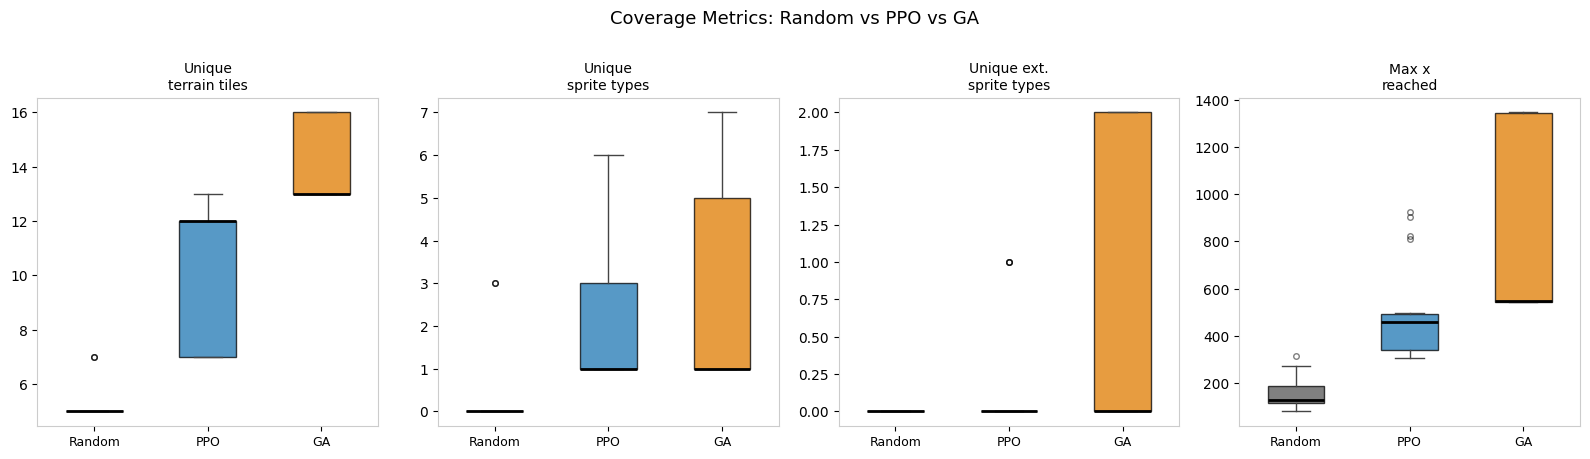

Saved → figures/boxplot_coverage.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
# ── Figure 1: Box plots of coverage metrics (3 agents) ──────────────────────
fig_metrics = [
    ('unique_terrain_tiles',    'Unique\nterrain tiles'),
    ('unique_sprite_types',     'Unique\nsprite types'),
    ('unique_ext_sprite_types', 'Unique ext.\nsprite types'),
    ('max_x',                   'Max x\nreached'),
]

COLORS = {
    'Random': '#555555',
    'PPO':    '#1f77b4',
    'GA':     '#e07b00',
}

fig, axes = plt.subplots(1, len(fig_metrics), figsize=(16, 4.5))
fig.patch.set_facecolor('white')

for ax, (key, label) in zip(axes, fig_metrics):
    ax.set_facecolor('white')
    data = [vals(res, key) for _, res in agents]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='#444444'),
        capprops=dict(color='#444444'),
        flierprops=dict(marker='o', color='#444444', markersize=4, alpha=0.5),
    )
    for patch, (name, _) in zip(bp['boxes'], agents):
        patch.set_facecolor(COLORS[name])
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([n for n, _ in agents], color='black', fontsize=9)
    ax.set_title(label, color='black', fontsize=10, pad=6)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

fig.suptitle('Coverage Metrics: Random vs PPO vs GA', color='black', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/boxplot_coverage.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('./figures/boxplot_coverage.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('Saved → figures/boxplot_coverage.pdf')

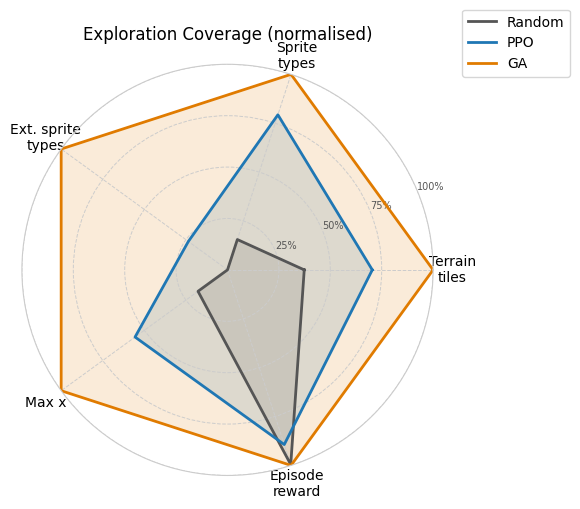

Saved → figures/radar_coverage.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
# ── Figure 2: Radar / spider chart (3 agents) ───────────────────────────────
radar_metrics = [
    ('unique_terrain_tiles',    'Terrain\ntiles'),
    ('unique_sprite_types',     'Sprite\ntypes'),
    ('unique_ext_sprite_types', 'Ext. sprite\ntypes'),
    ('max_x',                   'Max x'),
    ('episode_reward',          'Episode\nreward'),
]

means = {name: [np.mean(vals(res, k)) for k, _ in radar_metrics] for name, res in agents}
all_means = np.array(list(means.values()))
max_vals = all_means.max(axis=0)
max_vals[max_vals == 0] = 1
norm = {name: (np.array(m) / max_vals).tolist() for name, m in means.items()}

N = len(radar_metrics)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for name, nvals in norm.items():
    values = nvals + nvals[:1]
    ax.plot(angles, values, color=COLORS[name], linewidth=2, label=name)
    ax.fill(angles, values, color=COLORS[name], alpha=0.15)

ax.set_thetagrids(
    [a * 180 / math.pi for a in angles[:-1]],
    [label for _, label in radar_metrics],
    color='black', fontsize=10
)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='#555555', fontsize=7)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.7)
ax.spines['polar'].set_color('#cccccc')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='white', edgecolor='#cccccc',
          labelcolor='black', fontsize=10)
ax.set_title('Exploration Coverage (normalised)', color='black', pad=18, fontsize=12)

plt.tight_layout()
plt.savefig('./figures/radar_coverage.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('./figures/radar_coverage.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('Saved → figures/radar_coverage.pdf')


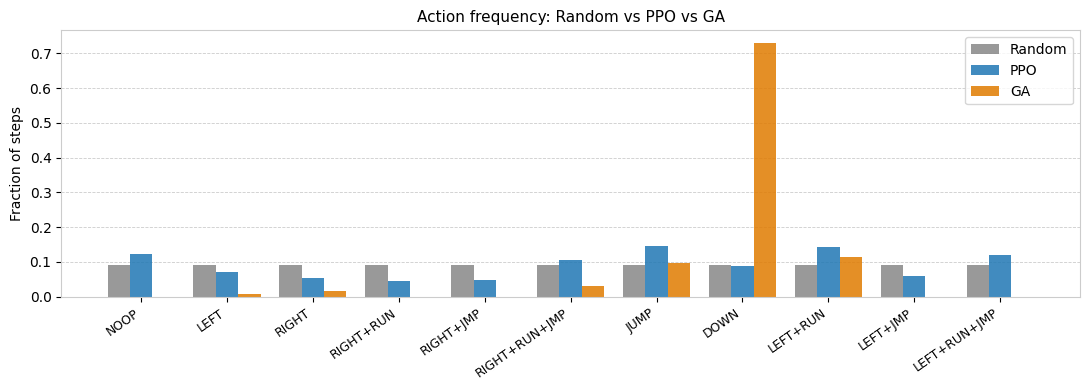

Saved → figures/action_hist_all.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
# ── Figure 3: Action frequency histogram — PPO and GA vs uniform random ────
def get_action_freq(results):
    total = np.zeros(N_ACTIONS)
    for r in results:
        total += np.array(r['action_counts'])
    return total / total.sum()

ppo_freq    = get_action_freq(ppo_results)
ga_freq     = get_action_freq(ga_results)
random_flat = np.ones(N_ACTIONS) / N_ACTIONS

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(N_ACTIONS)
width = 0.26

bars_rnd = ax.bar(x - width, random_flat, width, color=COLORS['Random'], alpha=0.6,  label='Random')
bars_ppo = ax.bar(x,          ppo_freq,   width, color=COLORS['PPO'],    alpha=0.85, label='PPO')
bars_ga  = ax.bar(x + width,  ga_freq,    width, color=COLORS['GA'],     alpha=0.85, label='GA')

ax.set_xticks(x)
ax.set_xticklabels(ACTION_NAMES, rotation=35, ha='right', color='black', fontsize=9)
ax.tick_params(axis='y', colors='black')
ax.set_ylabel('Fraction of steps', color='black')
ax.set_title('Action frequency: Random vs PPO vs GA', color='black', fontsize=11)

for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.yaxis.grid(True, color='#cccccc', linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(facecolor='white', edgecolor='#cccccc', labelcolor='black')

plt.tight_layout()
plt.savefig('./figures/action_hist_all.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('./figures/action_hist_all.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('Saved → figures/action_hist_all.pdf')


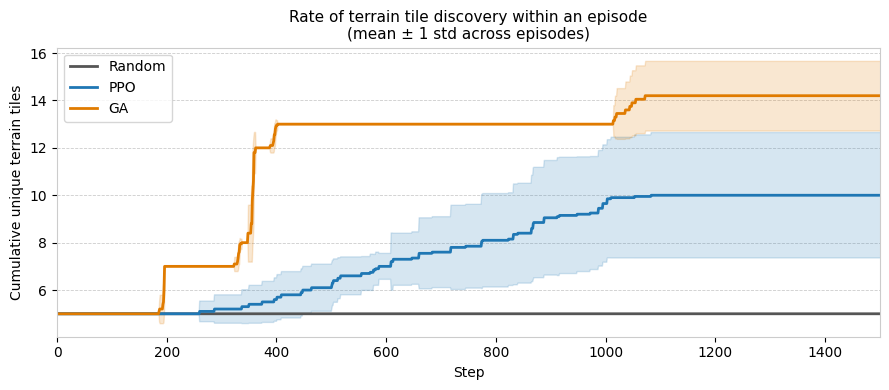

Saved → figures/discovery_curve.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# ── Figure 4: Cumulative unique terrain tiles discovered per step ────────────
def pad_curves(results, key='unique_tiles_over_time'):
    curves = [r[key] for r in results]
    max_len = max(len(c) for c in curves)
    return np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for name, res in agents:
    curves = pad_curves(res)
    mean = curves.mean(axis=0)
    std  = curves.std(axis=0)
    steps = np.arange(len(mean))
    ax.plot(steps, mean, color=COLORS[name], linewidth=2, label=name)
    ax.fill_between(steps, mean - std, mean + std, color=COLORS[name], alpha=0.18)

ax.set_xlabel('Step', color='black')
ax.set_ylabel('Cumulative unique terrain tiles', color='black')
ax.set_title('Rate of terrain tile discovery within an episode\n'
             '(mean ± 1 std across episodes)', color='black', fontsize=11)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.yaxis.grid(True, color='#cccccc', linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(facecolor='white', edgecolor='#cccccc', labelcolor='black')
ax.set_xlim(0, 1500)

plt.tight_layout()
plt.savefig('./figures/discovery_curve.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('./figures/discovery_curve.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('Saved → figures/discovery_curve.pdf')

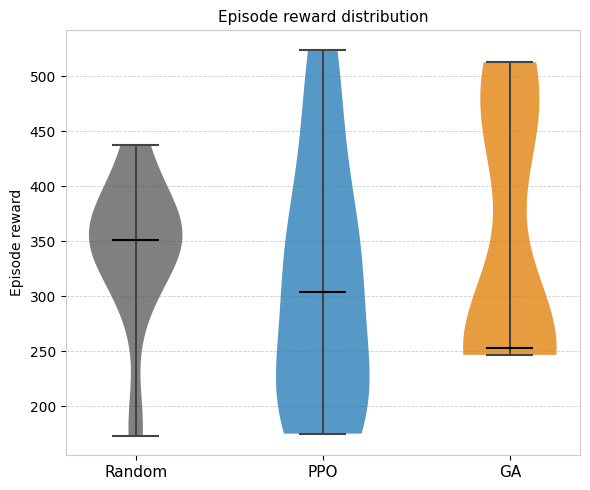

Saved → figures/reward_violin.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
# ── Figure 5: Episode reward distribution (violin plots) ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

data_all   = [vals(res, 'episode_reward') for _, res in agents]
labels_all = [name for name, _ in agents]

parts = ax.violinplot(data_all, positions=[1, 2, 3], showmedians=True, showextrema=True)
for pc, (name, _) in zip(parts['bodies'], agents):
    pc.set_facecolor(COLORS[name])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmaxes'].set_color('#444444')
parts['cmins'].set_color('#444444')
parts['cbars'].set_color('#444444')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels_all, color='black', fontsize=11)
ax.tick_params(axis='y', colors='black')
ax.set_ylabel('Episode reward', color='black')
ax.set_title('Episode reward distribution', color='black', fontsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.yaxis.grid(True, color='#cccccc', linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./figures/reward_violin.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('./figures/reward_violin.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print('Saved → figures/reward_violin.pdf')

## 8. Print LaTeX-ready table

In [26]:
def fmt(results, key, fmt_str='{:.1f}'):
    v = vals(results, key)
    return f'{fmt_str.format(np.mean(v))} $\\pm$ {fmt_str.format(np.std(v))}'

rows = [
    ('Episode reward',             'episode_reward',          '{:.1f}'),
    ('Unique terrain tiles',       'unique_terrain_tiles',    '{:.0f}'),
    ('Unique sprite types',        'unique_sprite_types',     '{:.0f}'),
    ('Unique ext.\\ sprite types',  'unique_ext_sprite_types', '{:.0f}'),
    ('Max $x$-coord.\ reached',    'max_x',                   '{:.0f}'),
    ('Total tile interactions',    'tile_interactions',       '{:.0f}'),
    ('Deaths per episode',         'deaths',                  '{:.1f}'),
    ('Action entropy $H$',         'action_entropy',          '{:.2f}'),
]

print('% ── Paste into your LaTeX report ──────────────────────────────────')
print('\\begin{table}[H]')
print('  \\centering')
print(f'  \\caption{{Exploration metrics (mean $\\pm$ std over {N_EPISODES} episodes).}}')
print('  \\label{tab:main_results}')
print('  \\begin{tabular}{lrrr}')
print('    \\toprule')
print('    Metric & Random & PPO & GA \\\\')
print('    \\midrule')
for name, key, fstr in rows:
    r = fmt(random_results, key, fstr)
    p = fmt(ppo_results,    key, fstr)
    g = fmt(ga_results,     key, fstr)
    print(f'    {name} & {r} & {p} & {g} \\\\')
goals_r = sum(r['goal_reached'] for r in random_results)
goals_p = sum(r['goal_reached'] for r in ppo_results)
goals_g = sum(r['goal_reached'] for r in ga_results)
print(f'    Secret exit found & {goals_r}/{N_EPISODES} & {goals_p}/{N_EPISODES} & {goals_g}/{N_EPISODES} \\\\')
print('    \\bottomrule')
print('  \\end{tabular}')
print('\\end{table}')


% ── Paste into your LaTeX report ──────────────────────────────────
\begin{table}[H]
  \centering
  \caption{Exploration metrics (mean $\pm$ std over 20 episodes).}
  \label{tab:main_results}
  \begin{tabular}{lrrr}
    \toprule
    Metric & Random & PPO & GA \\
    \midrule
    Episode reward & 279.4 $\pm$ 82.2 & 307.0 $\pm$ 109.0 & 343.7 $\pm$ 112.4 \\
    Unique terrain tiles & 5 $\pm$ 0 & 10 $\pm$ 3 & 14 $\pm$ 1 \\
    Unique sprite types & 0 $\pm$ 0 & 2 $\pm$ 2 & 3 $\pm$ 2 \\
    Unique ext.\ sprite types & 0 $\pm$ 0 & 0 $\pm$ 0 & 1 $\pm$ 1 \\
    Max $x$-coord.\ reached & 134 $\pm$ 47 & 491 $\pm$ 199 & 884 $\pm$ 386 \\
    Total tile interactions & 0 $\pm$ 0 & 0 $\pm$ 0 & 0 $\pm$ 0 \\
    Deaths per episode & 0.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 \\
    Action entropy $H$ & 2.40 $\pm$ 0.00 & 2.31 $\pm$ 0.02 & 0.82 $\pm$ 0.06 \\
    Secret exit found & 0/20 & 0/20 & 0/20 \\
    \bottomrule
  \end{tabular}
\end{table}


<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_28256/3943127858.py:10: SyntaxWarning: invalid escape sequence '\ '
  ('Max $x$-coord.\ reached',    'max_x',                   '{:.0f}'),


## 9. Save raw results for later use (GA comparison, etc.)

In [31]:
import json

def serialise(results):
    out = []
    for r in results:
        entry = {k: (v.tolist() if hasattr(v, 'tolist') else v) for k, v in r.items()}
        out.append(entry)
    return out

with open('./figures/random_results.json', 'w') as f:
    json.dump(serialise(random_results), f, indent=2)
with open('./figures/ppo_results.json', 'w') as f:
    json.dump(serialise(ppo_results), f, indent=2)
with open('./figures/ga_results.json', 'w') as f:
    json.dump(serialise(ga_results), f, indent=2)

print('Saved: random_results.json, ppo_results.json, ga_results.json')


Saved: random_results.json, ppo_results.json, ga_results.json
